## **Layer 3 Decision & Policy Layer**

In [6]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
import pandas_ta as ta

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

current_working_dir = os.getcwd()
if os.path.basename(current_working_dir) == "layers":
    PROJECT_ROOT = os.path.abspath(os.path.join(current_working_dir, ".."))
else:
    PROJECT_ROOT = current_working_dir

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Define data path
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
# Load the data that now includes signals
SIGNALS_DATA_FILE = os.path.join(DATA_DIR, "market_data_signals.parquet")

print(f"Project root set to: {PROJECT_ROOT}")
print(f"Loading data with signals from: {SIGNALS_DATA_FILE}")

try:
    # Load the data processed by Layer 1 and Layer 2
    df = pd.read_parquet(SIGNALS_DATA_FILE)
    print("Successfully loaded data with signals.")
except FileNotFoundError:
    print("Error: Data file 'market_data_signals.parquet' not found.")
    print("Please ensure Layer 1 and Layer 2 notebooks have been run and saved the data.")
    df = pd.DataFrame()

if not df.empty:
    print("\nVerifying required columns ('regime', 'signal'):")
    print(df[['datetime', 'close', 'regime', 'signal']].head())

Project root set to: /Users/raoabdul/Documents/Development/Trading-Bot-Algo
Loading data with signals from: /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_data_signals.parquet
Successfully loaded data with signals.

Verifying required columns ('regime', 'signal'):
                   datetime       close                  regime      signal
0 2026-01-12 14:43:00+00:00  257.140015                 Unknown     Neutral
1 2026-01-12 14:44:00+00:00  257.549988     Downtrend - Impulse   Exit Long
2 2026-01-12 14:45:00+00:00  257.774994     Downtrend - Impulse   Exit Long
3 2026-01-12 14:46:00+00:00  258.200012  Ranging - Accumulation  Enter Long
4 2026-01-12 14:47:00+00:00  258.109985  Ranging - Uptrend Bias     Neutral


## **Backtest Simulation**

### **Letting Winners Run : Trailing Stop-Loss**
The New Solution: We replaced the simple signal-based exit with a **dynamic Trailing Stop-Loss**
  - **How it Works** : When you enter a trade (e.g., at $260 with a 1% trailing stop), the initial stop-loss is set at $257.40. If the stock price rises to a new high of $265, your stop-loss automatically moves up to $262.35 (1% below the new peak)
  
  - **The Impact on Profit** : This is the key to capturing large trends. The bot now stays in a winning trade for as long as it keeps making new highs. It only sells when the trend finally reverses and the price drops by our specified percentage from its peak, locking in a much larger profit than before.


### **Descriptive Signals**
The Old Problem: The generic 'Bullish' and 'Bearish' signals were causing confusion. A 'Bearish' signal could mean "exit a long trade" or "enter a short trade," leading to misaligned logic and too many unnecessary trades.

* **The New Solution** : We created more descriptive signals to separate the reason for the action.
  * `'Enter Long'`: This signal is now generated only for high-probability entry setups, like an 'Uptrend - Pullback' or 'Ranging - Accumulation'. The bot no longer tries to buy on every minor sign of bullishness.
  
  * `'Exit Long'`: This signal is now generated specifically when an uptrend shows signs of weakness or reversal (e.g., the regime becomes 'Uptrend - Overbought' or 'Downtrend - Impulse').

* **The Impact on Profit** : This clear separation between entry and exit logic makes
  the bot's decisions much more deliberate. It reduces the number of low-quality
  trades taken in uncertain conditions, which helps prevent the "death by a
  thousand cuts" from small, repeated losses.

In [7]:
if not df.empty:
    # --- Backtest Configuration ---
    initial_capital = 100000.0
    INVEST_DOLLAR_AMOUNT_PER_TRADE = 5000.0
    TRAILING_STOP_PERCENTAGE = 0.01  # 1% trailing stop

    # --- State Tracking & Logging ---
    df['position_shares'] = 0
    df['cash'] = initial_capital
    df['portfolio_value'] = initial_capital
    trades_log = [] 
    
    # --- Per-Trade State Variables ---
    shares_in_position = 0
    buy_price_per_share = 0.0
    highest_price_since_buy = 0.0
    
    # --- Simulation Loop ---
    for i in range(1, len(df)):
        # Carry over portfolio state from previous day
        df.loc[i, 'cash'] = df.loc[i-1, 'cash']
        df.loc[i, 'position_shares'] = df.loc[i-1, 'position_shares']
        
        current_close_price = df.loc[i, 'close']
        signal = df.loc[i, 'signal']
        
        # --- Logic when IN a position ---
        if shares_in_position > 0:
            highest_price_since_buy = max(highest_price_since_buy, current_close_price)
            trailing_stop_price = highest_price_since_buy * (1 - TRAILING_STOP_PERCENTAGE)

            # Check for exit conditions
            if signal == 'Exit Long' or current_close_price <= trailing_stop_price:
                exit_type = 'SELL (Signal)' if signal == 'Exit Long' else 'SELL (Trail SL)'
                
                pnl_dollars = (current_close_price - buy_price_per_share) * shares_in_position
                df.loc[i, 'cash'] += current_close_price * shares_in_position
                df.loc[i, 'position_shares'] = 0
                
                trades_log.append({
                    'Type': exit_type, 
                    'Entry Price': buy_price_per_share,
                    'Exit Date': df.loc[i, 'datetime'], 
                    'Exit Price': current_close_price,
                    'Quantity': shares_in_position, 
                    'P/L ($)': pnl_dollars,
                    'Signal': signal if exit_type == 'SELL (Signal)' else 'TRAIL_STOP', 
                    'Regime': df.loc[i, 'regime']
                })
                
                # Reset trade variables
                shares_in_position, buy_price_per_share, highest_price_since_buy = 0, 0, 0

        # --- Logic when NOT in a position ---
        elif shares_in_position == 0:
            if signal == 'Enter Long':
                num_shares_to_buy = np.floor(INVEST_DOLLAR_AMOUNT_PER_TRADE / current_close_price)
                if num_shares_to_buy > 0 and df.loc[i, 'cash'] >= (num_shares_to_buy * current_close_price):
                    df.loc[i, 'position_shares'] = num_shares_to_buy
                    df.loc[i, 'cash'] -= num_shares_to_buy * current_close_price
                    
                    buy_price_per_share = current_close_price 
                    shares_in_position = num_shares_to_buy
                    highest_price_since_buy = current_close_price
                    
                    trades_log.append({
                        'Type': 'BUY', 
                        'Entry Date': df.loc[i, 'datetime'],
                        'Entry Price': current_close_price, 
                        'Quantity': num_shares_to_buy
                    })

        # Update daily portfolio valuation
        df.loc[i, 'portfolio_value'] = df.loc[i, 'cash'] + (df.loc[i, 'position_shares'] * current_close_price)
     
    print("Backtest simulation complete.")

Backtest simulation complete.


## **Performance Analysis and Visualization**


--- Backtest Performance Metrics ---
Initial Capital:          $100,000.00
Final Portfolio Value:    $100,009.28
Strategy Total Return:    0.01%
Buy & Hold Total Return:  1.19%
Maximum Drawdown:         -0.01%


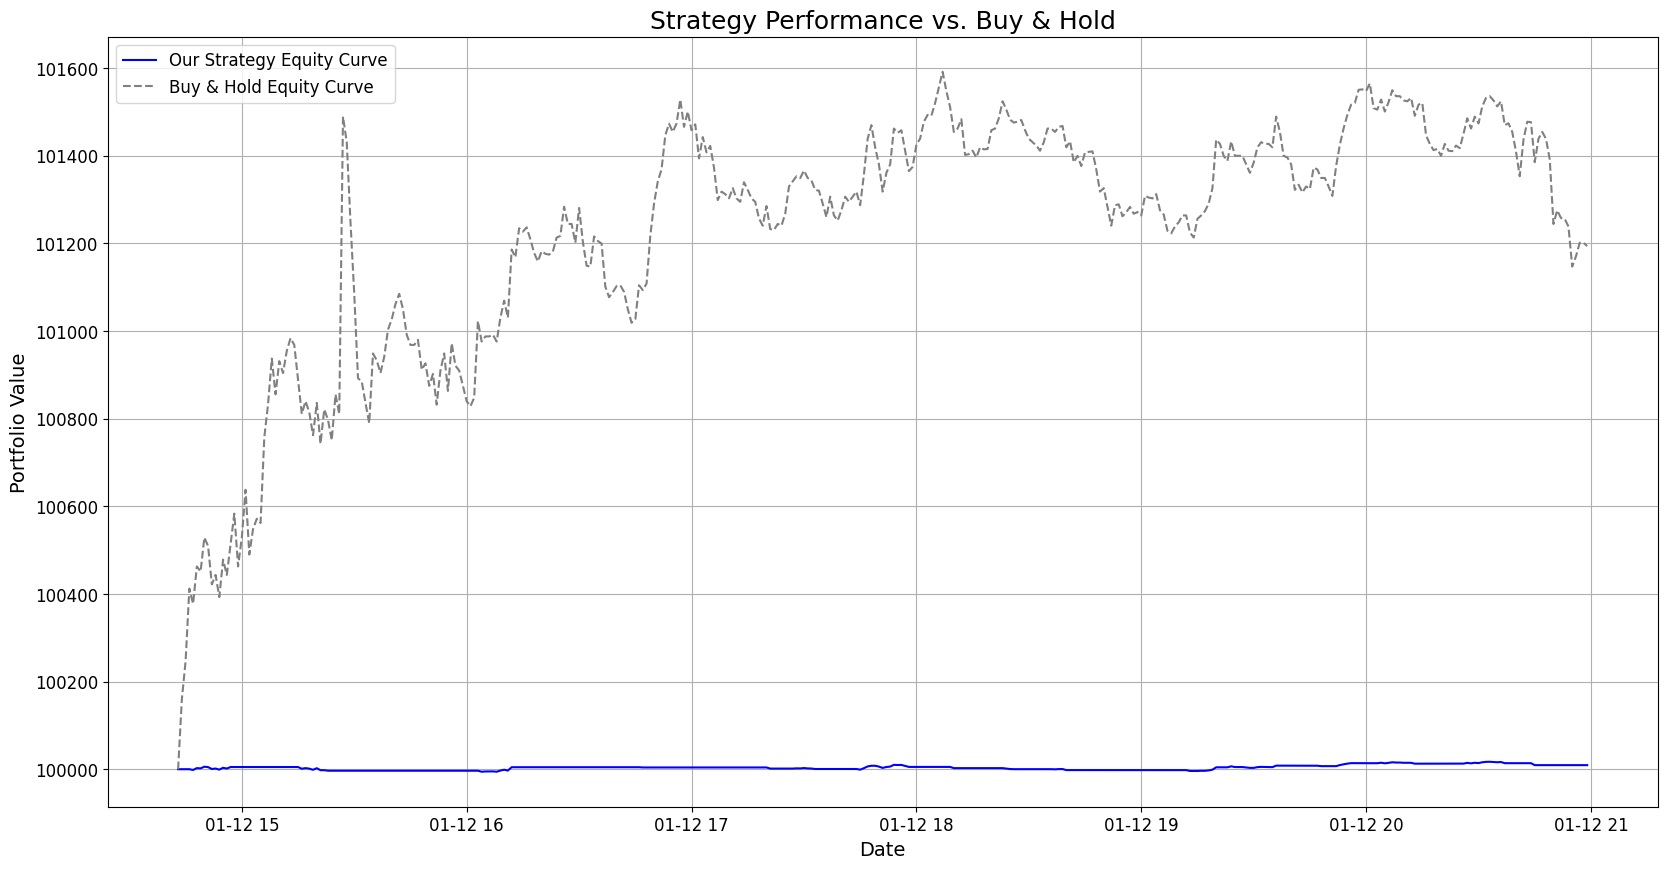

In [8]:
if not df.empty:
    # --- Performance Metrics (Layer 4) ---
    final_portfolio_value = df['portfolio_value'].iloc[-1]
    total_return_pct = ((final_portfolio_value / initial_capital) - 1) * 100
    
    # Calculate Buy & Hold return for comparison
    buy_hold_return_pct = ((df['close'].iloc[-1] / df['close'].iloc[0]) - 1) * 100
    
    # Calculate Max Drawdown (critical risk metric)
    rolling_max = df['portfolio_value'].cummax()  # Get the running maximum
    daily_drawdown = df['portfolio_value'] / rolling_max - 1.0  # Calculate daily drawdown
    max_drawdown_pct = daily_drawdown.min() * 100  # Find the largest drawdown

    print("\n--- Backtest Performance Metrics ---")
    print(f"Initial Capital:          ${initial_capital:,.2f}")
    print(f"Final Portfolio Value:    ${final_portfolio_value:,.2f}")
    print(f"Strategy Total Return:    {total_return_pct:.2f}%")
    print(f"Buy & Hold Total Return:  {buy_hold_return_pct:.2f}%")
    print(f"Maximum Drawdown:         {max_drawdown_pct:.2f}%")
    
    # --- Visualization ---
    plt.figure(figsize=(20, 10))
    
    # Plot our strategy's equity curve
    plt.plot(df['datetime'], df['portfolio_value'], label='Our Strategy Equity Curve', color='blue')
    
    # Plot Buy & Hold equity curve for comparison
    buy_hold_equity = (df['close'] / df['close'].iloc[0]) * initial_capital
    plt.plot(df['datetime'], buy_hold_equity, label='Buy & Hold Equity Curve', color='gray', linestyle='--')
    
    plt.title('Strategy Performance vs. Buy & Hold', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Portfolio Value', fontsize=14)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True)
    plt.show()


--- Backtest Performance Metrics ---
Initial Capital:           $100,000.00
Final Portfolio Value:     $100,009.28
Strategy Total Return:     0.01%
Buy & Hold Total Return:   1.19%
Maximum Drawdown:          -0.01%


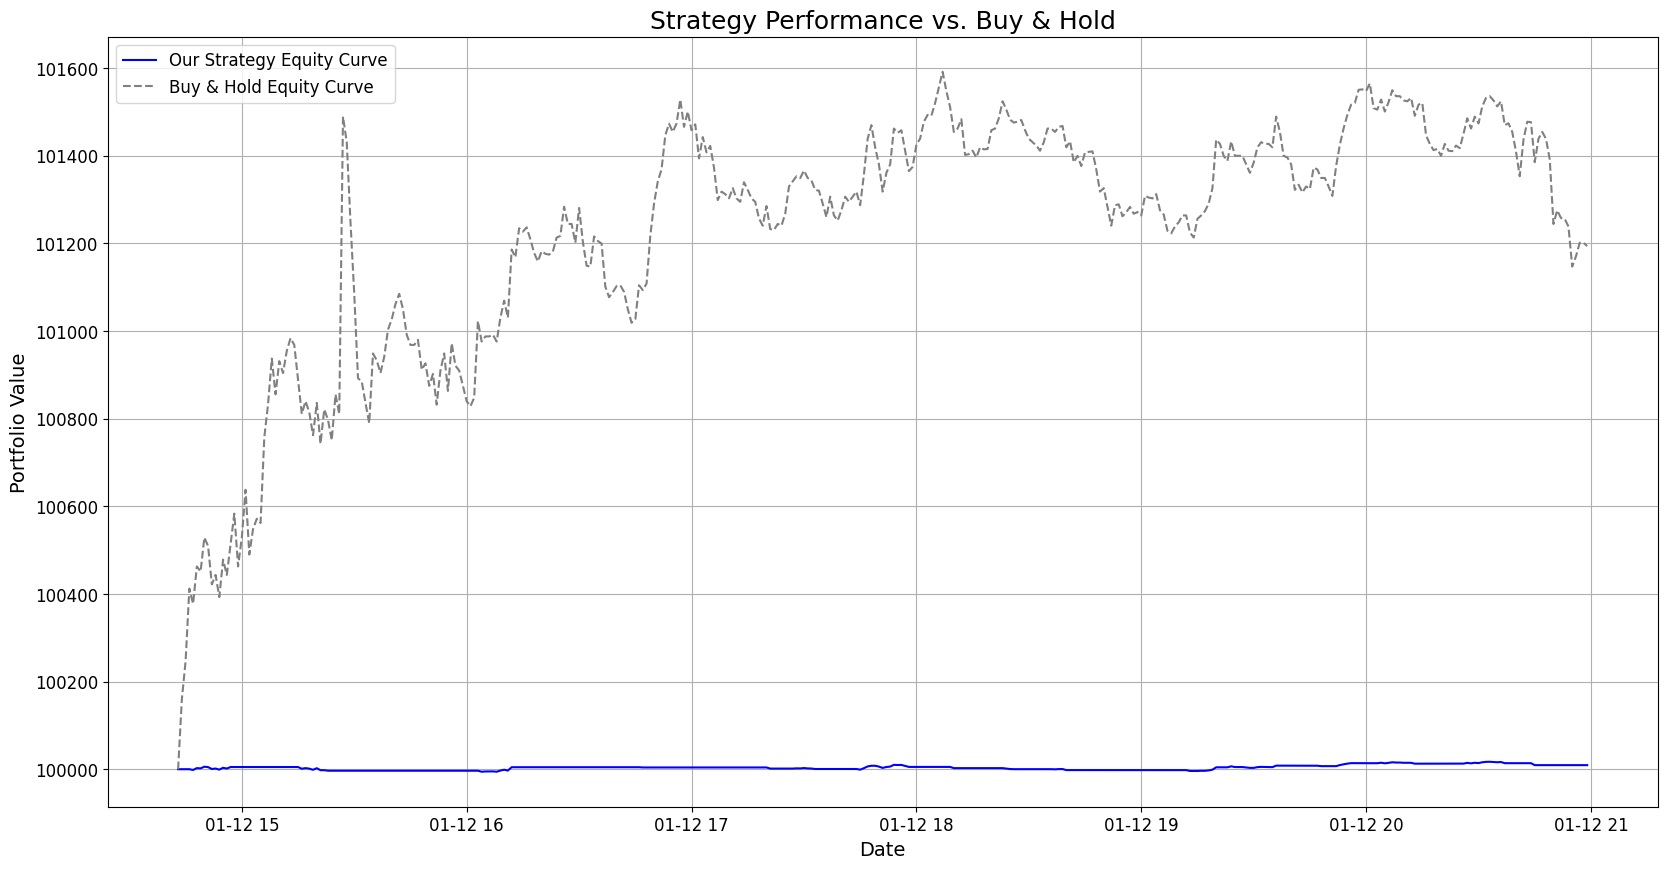


--- Trading Activity Summary ---
Number of Buy Trades: 25
Number of Sell Trades: 25
Total Trades: 50


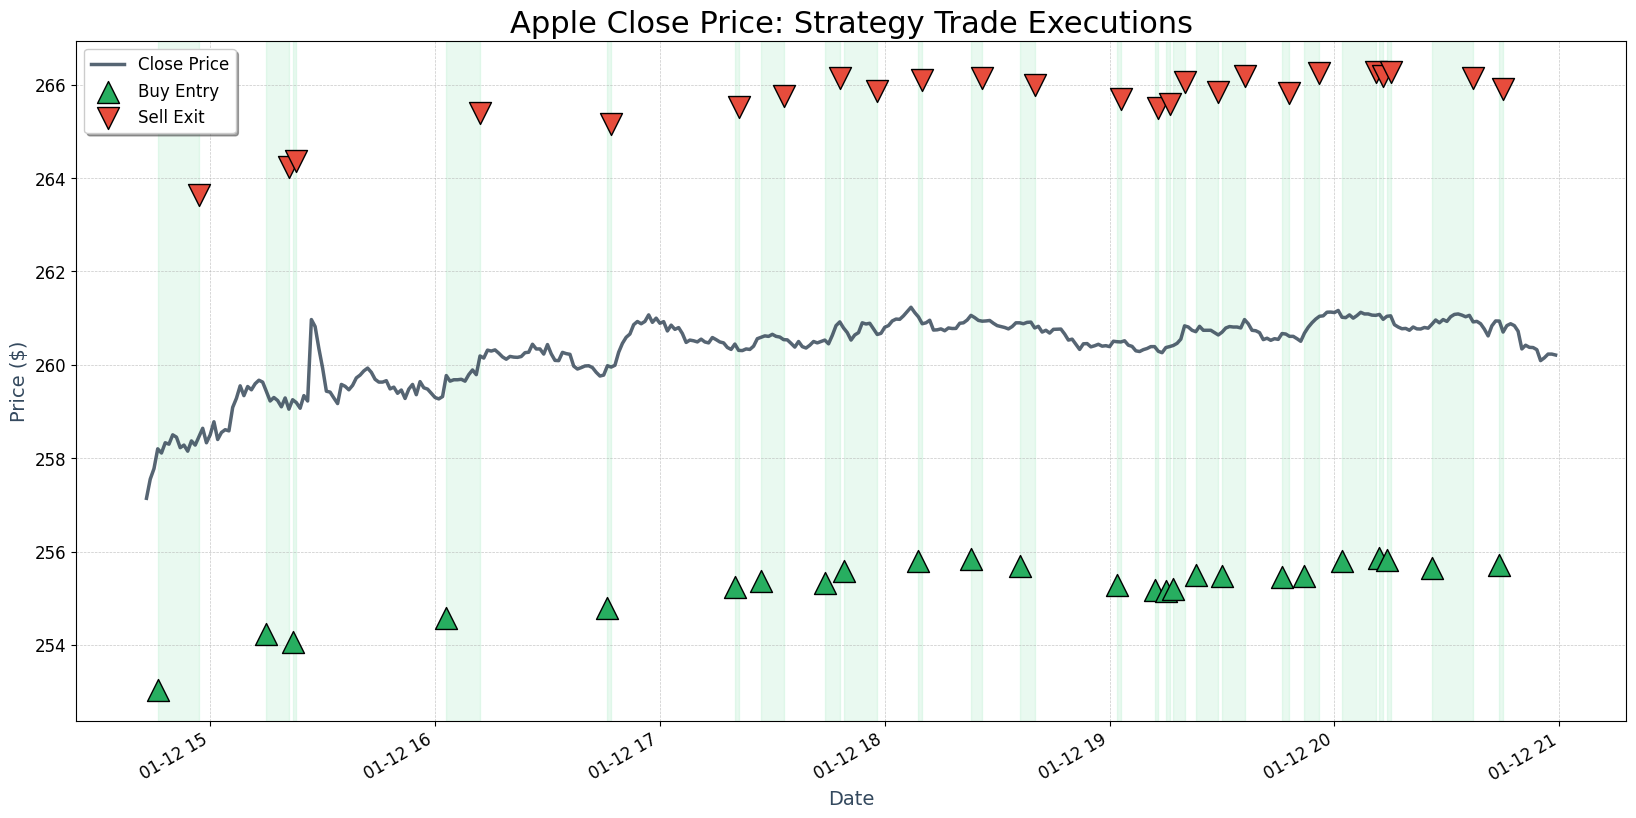

In [9]:
if not df.empty:
    # --- Performance Metrics ---
    final_portfolio_value = df['portfolio_value'].iloc[-1]
    total_return_pct = ((final_portfolio_value / initial_capital) - 1) * 100
    
    buy_hold_return_pct = ((df['close'].iloc[-1] / df['close'].iloc[0]) - 1) * 100
    
    rolling_max = df['portfolio_value'].cummax()
    daily_drawdown = df['portfolio_value'] / rolling_max - 1.0
    max_drawdown_pct = daily_drawdown.min() * 100

    print("\n--- Backtest Performance Metrics ---")
    print(f"Initial Capital:           ${initial_capital:,.2f}")
    print(f"Final Portfolio Value:     ${final_portfolio_value:,.2f}")
    print(f"Strategy Total Return:     {total_return_pct:.2f}%")
    print(f"Buy & Hold Total Return:   {buy_hold_return_pct:.2f}%")
    print(f"Maximum Drawdown:          {max_drawdown_pct:.2f}%")
    
    # --- Equity Curve Visualization ---
    plt.figure(figsize=(20, 10))
    plt.plot(df['datetime'], df['portfolio_value'], label='Our Strategy Equity Curve', color='blue')
    
    buy_hold_equity = (df['close'] / df['close'].iloc[0]) * initial_capital
    plt.plot(df['datetime'], buy_hold_equity, label='Buy & Hold Equity Curve', color='gray', linestyle='--')
    
    plt.title('Strategy Performance vs. Buy & Hold', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Portfolio Value', fontsize=14)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True)
    plt.show()

    # --- Trading Activity Summary ---
    # Logic to identify transition points where shares were bought or sold
    num_buys = df[(df['position_shares'].shift(1) == 0) & (df['position_shares'] > 0)].shape[0]
    num_sells = df[(df['position_shares'].shift(1) > 0) & (df['position_shares'] == 0)].shape[0]
    
    print("\n--- Trading Activity Summary ---")
    print(f"Number of Buy Trades: {num_buys}")
    print(f"Number of Sell Trades: {num_sells}")
    print(f"Total Trades: {num_buys + num_sells}")

    # --- Trade Visualization on Price Chart ---
    plt.figure(figsize=(20, 10))
    
    # Plot the Close Price with a sleek dark line
    plt.plot(df['datetime'], df['close'], label='Close Price', color='#2c3e50', linewidth=2.5, alpha=0.8)
    
    # Mark Buy Signals: Using a larger 'up' arrow with a black edge
    buy_signals = df[(df['position_shares'].shift(1) == 0) & (df['position_shares'] > 0)]
    plt.scatter(buy_signals['datetime'], buy_signals['close'] * 0.98, # Offset slightly below price
                marker='^', color='#27ae60', s=250, label='Buy Entry', 
                edgecolors='black', linewidths=1, zorder=5)
    
    # Mark Sell Signals: Using a larger 'down' arrow with a black edge
    sell_signals = df[(df['position_shares'].shift(1) > 0) & (df['position_shares'] == 0)]
    plt.scatter(sell_signals['datetime'], sell_signals['close'] * 1.02, # Offset slightly above price
                marker='v', color='#e74c3c', s=250, label='Sell Exit', 
                edgecolors='black', linewidths=1, zorder=5)
    
    # Optional: Add vertical lines to connect the trade points
    for buy_date, sell_date in zip(buy_signals['datetime'], sell_signals['datetime']):
        plt.axvspan(buy_date, sell_date, color='#2ecc71', alpha=0.1) # Soft green background for trade duration

    # Refined Styling
    plt.title('Apple Close Price: Strategy Trade Executions', fontsize=22)
    plt.xlabel('Date', fontsize=14, color='#34495e')
    plt.ylabel('Price ($)', fontsize=14, color='#34495e')
    
    # Legend with a frame
    plt.legend(loc='upper left', fontsize=12, frameon=True, shadow=True)
    
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.gcf().autofmt_xdate()
    plt.show()

else:
    print("DataFrame is empty, cannot perform analysis or visualizations.")

In [10]:
num_buys = df[(df['position_shares'].shift(1) == 0) & (df['position_shares'] > 0)].shape[0]
num_sells = df[(df['position_shares'].shift(1) > 0) & (df['position_shares'] == 0)].shape[0]

print("\n--- Trading Activity Summary ---")
print(f"Number of Buy Trades: {num_buys}")
print(f"Number of Sell Trades: {num_sells}")
print(f"Total Trades: {num_buys + num_sells}")


--- Trading Activity Summary ---
Number of Buy Trades: 25
Number of Sell Trades: 25
Total Trades: 50
